In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron as Perceptron_S
from sklearn.model_selection import cross_val_score

In [209]:
data = {
    'A': [0, 0, 1, 1],
    'B': [0, 1, 0, 1],
    'y': [1, 1, 1, 0]
}


In [210]:
data = pd.DataFrame(data)
data

,A,B,y
0,0,0,1
1,0,1,1
2,1,0,1
3,1,1,0


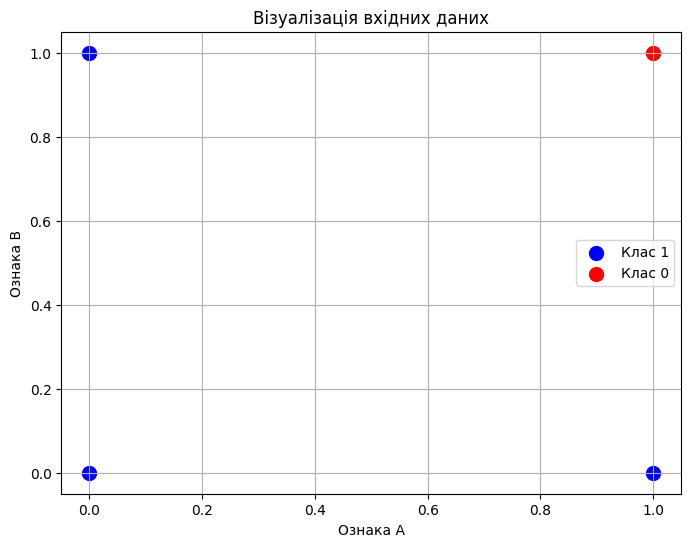

In [211]:
plt.figure(figsize=(8, 6))

plt.scatter(data[data['y'] == 1]['A'],
            data[data['y'] == 1]['B'],
            color='blue',
            label='Клас 1',
            marker='o',
            s=100)
plt.scatter(data[data['y'] == 0]['A'],
            data[data['y'] == 0]['B'],
            color='red',
            label='Клас 0',
            marker='o', s=100)

plt.title('Візуалізація вхідних даних')
plt.xlabel('Ознака A')
plt.ylabel('Ознака B')
plt.legend()
plt.grid(True)
plt.show()

In [212]:
X = data[['A', 'B']].to_numpy()

In [213]:
y = data['y'].to_numpy()
y[y == 0] = -1

In [214]:
class Perceptron():
  def __init__(self, learning_rate=0.01, n_iters=50):
      self.learning_rate = learning_rate
      self.n_iters = n_iters
      self.weights = None

  def fit(self, X, y):
    n_samples, n_features = X.shape
    X_b = np.hstack((X, np.ones((n_samples, 1))))
    self.weights = np.zeros(n_features+1)
    X_prime = X_b * y[:, np.newaxis]
    for _ in range(self.n_iters):
      np.random.shuffle(X_prime)
      for i in X_prime:
        if np.dot(self.weights, i) <= 0:
          self.weights += self.learning_rate * i

  def predict(self, X):
    n_samples = X.shape[0]
    X_b = np.hstack((X, np.ones((n_samples, 1))))
    y_predicted = np.where(np.dot(X_b, self.weights) >= 0, 1, -1)
    return y_predicted

  def score(self, X, y):
    y_pred = self.predict(X)
    return accuracy_score(y, y_pred)

  def get_params(self, deep=True):
    return {"learning_rate": self.learning_rate, "n_iters": self.n_iters}

  def set_params(self, **params):
    for param, value in params.items():
      setattr(self, param, value)
    return self

In [215]:
percepton_test = Perceptron()

percepton_test.fit(X, y)

In [216]:
W = percepton_test.weights
W

array([-0.02, -0.02,  0.03])

In [217]:
def print_computation(A, B, y_true, w0, w1, w2):

    z =  (w0 * A) + (w1 * B) + w2

    prediction = 1 if z >= 0 else 0

    result_status = "Правильно" if prediction == y_true else "Помилка"

    print(f"--- Обчислення для входу (A={A}, B={B}) ---")
    print(f"Формула суми: z = w0*A + w1*B + w2")
    print(f"Підстановка ваг: z =  ({w0} * {A}) + ({w0} * {B}) + {w2} = {z}")
    print(f"Функція активації: оскільки z = {z} ({'>=' if z >= 0 else '<'} 0), то прогноз = {prediction}")
    print(f"Перевірка: Прогноз ({prediction}) == Правильна відповідь ({y_true}) -> {result_status}")
    print("-" * 45 + "\n")


In [218]:
w0, w1, w2 = W[0], W[1], W[2]

In [222]:
print_computation(0, 0, 1, w0, w1, w2)
print_computation(0, 1, 1, w0, w1, w2)
print_computation(1, 0, 1, w0, w1, w2)
print_computation(1, 1, 0, w0, w1, w2)

--- Обчислення для входу (A=0, B=0) ---
Формула суми: z = w0*A + w1*B + w2
Підстановка ваг: z =  (-0.02 * 0) + (-0.02 * 0) + 0.03 = 0.03
Функція активації: оскільки z = 0.03 (>= 0), то прогноз = 1
Перевірка: Прогноз (1) == Правильна відповідь (1) -> Правильно
---------------------------------------------

--- Обчислення для входу (A=0, B=1) ---
Формула суми: z = w0*A + w1*B + w2
Підстановка ваг: z =  (-0.02 * 0) + (-0.02 * 1) + 0.03 = 0.010000000000000002
Функція активації: оскільки z = 0.010000000000000002 (>= 0), то прогноз = 1
Перевірка: Прогноз (1) == Правильна відповідь (1) -> Правильно
---------------------------------------------

--- Обчислення для входу (A=1, B=0) ---
Формула суми: z = w0*A + w1*B + w2
Підстановка ваг: z =  (-0.02 * 1) + (-0.02 * 0) + 0.03 = 0.009999999999999998
Функція активації: оскільки z = 0.009999999999999998 (>= 0), то прогноз = 1
Перевірка: Прогноз (1) == Правильна відповідь (1) -> Правильно
---------------------------------------------

--- Обчислення 

$w_0 \cdot x_0 + w_1 \cdot x_1 + w_2 =0$  
$ x_1 = (- w_2 - w_0 \cdot x_0) / w_1 $

In [220]:
x_line = np.linspace(-0.1, 1.5, 100)
y_line = -(w0 * x_line + w2) / w1


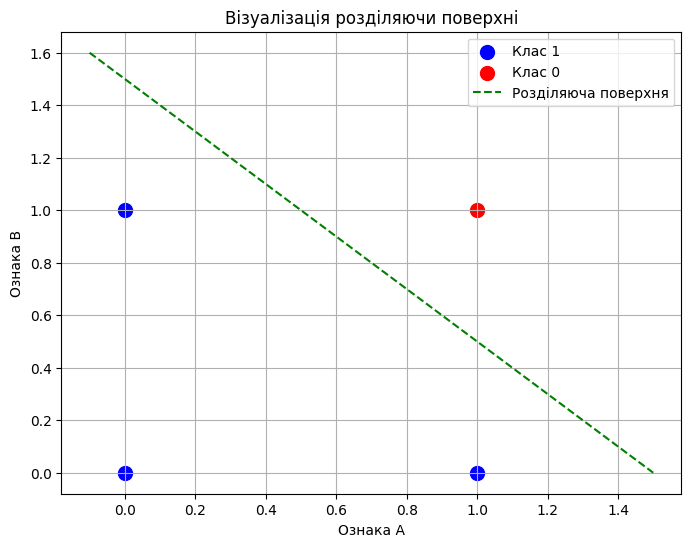

In [221]:
plt.figure(figsize=(8, 6))

plt.scatter(data[data['y'] == 1]['A'],
            data[data['y'] == 1]['B'],
            color='blue',
            label='Клас 1',
            marker='o',
            s=100)
plt.scatter(data[data['y'] == -1]['A'],
            data[data['y'] == -1]['B'],
            color='red',
            label='Клас 0',
            marker='o', s=100)
plt.plot(x_line, y_line, color='green', linestyle='--', label='Розділяюча поверхня')
plt.title('Візуалізація розділяючи поверхні')
plt.xlabel('Ознака A')
plt.ylabel('Ознака B')
plt.legend()
plt.grid(True)
plt.show()